# 卷积神经网络（LeNet）

LeNet，是最早发布的卷积神经网络之一，因其在计算机视觉任务中的高效性能而受到广泛关注。
这个模型是由AT&T贝尔实验室的研究员Yann LeCun在1989年提出的（并以其命名），目的是识别图像 :cite:`LeCun.Bottou.Bengio.ea.1998`中的手写数字。
当时，Yann LeCun发表了第一篇通过反向传播成功训练卷积神经网络的研究，这项工作代表了十多年来神经网络研究开发的成果。

当时，LeNet取得了与支持向量机（support vector machines）性能相媲美的成果，成为监督学习的主流方法。
LeNet被广泛用于自动取款机（ATM）机中，帮助识别处理支票的数字。

## LeNet

总体来看，(**LeNet（LeNet-5）由两个部分组成：**)(~~卷积编码器和全连接层密集块~~)

* 卷积编码器：由两个卷积层组成;
* 全连接层密集块：由三个全连接层组成。

该架构如 :numref:`img_lenet`所示。

![LeNet中的数据流。输入是手写数字，输出为10种可能结果的概率。](../img/lenet.svg)
:label:`img_lenet`

### 结构解释

**每个卷积块中的基本单元是一个卷积层、一个sigmoid激活函数和平均汇聚层。**
请注意，虽然ReLU和最大汇聚层更有效，但它们在20世纪90年代还没有出现。每个卷积层使用$5\times 5$卷积核和一个sigmoid激活函数。这些层将输入映射到多个二维特征输出，通常同时**增加通道的数量**。第一卷积层有6个输出通道，而第二个卷积层有16个输出通道。每个$2\times2$池操作（步幅2）通过**空间下采样**将维数减少4倍。卷积的输出形状由批量大小、通道数、高度、宽度决定。

为了将卷积块的输出传递给稠密块，我们必须在小批量中**展平**每个样本。换言之，我们将这个四维输入转换成全连接层所期望的二维输入。这里的二维表示的第一个维度索引小批量中的样本，第二个维度给出每个样本的平面向量表示。LeNet的稠密块有三个全连接层，分别有120、84和10个输出。因为我们在执行分类任务，所以输出层的10维对应于最后输出结果的数量。

## 代码实现

In [1]:
import torch
from d2l import torch as d2l
from torch import nn

# 解决绘图导致内核崩溃
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16*5*5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10)
)

In [2]:
# 检查网络是否正确
X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__, 'output shape: \t', X.shape)

Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
Sigmoid output shape: 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
Sigmoid output shape: 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Flatten output shape: 	 torch.Size([1, 400])
Linear output shape: 	 torch.Size([1, 120])
Sigmoid output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
Sigmoid output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


### 模型训练

In [3]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size=batch_size)

In [5]:
def evaluate_accuracy_gpu(net, data_iter, device=None):
    """使用GPU计算模型在数据集上的精度"""
    if isinstance(net, nn.Module):
        net.eval()
        if not device:
            device = next(iter(net.parameters())).device
    # 统计数量
    metric = d2l.Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(d2l.accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

In [6]:
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """用GPU训练模型(在第六章定义)"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    
    print("training on", device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = d2l.Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

loss 0.461, train acc 0.826, test acc 0.824
68750.3 examples/sec on cuda:0


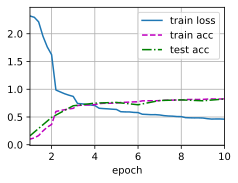

In [7]:
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

## 激活值可视化

我们分别输入毛衣（pullover）和外套（coat）样本，观察LeNet第一层（6通道）和第二层（16通道）卷积输出的激活值，理解不同输入在网络不同层中的特征表示差异。

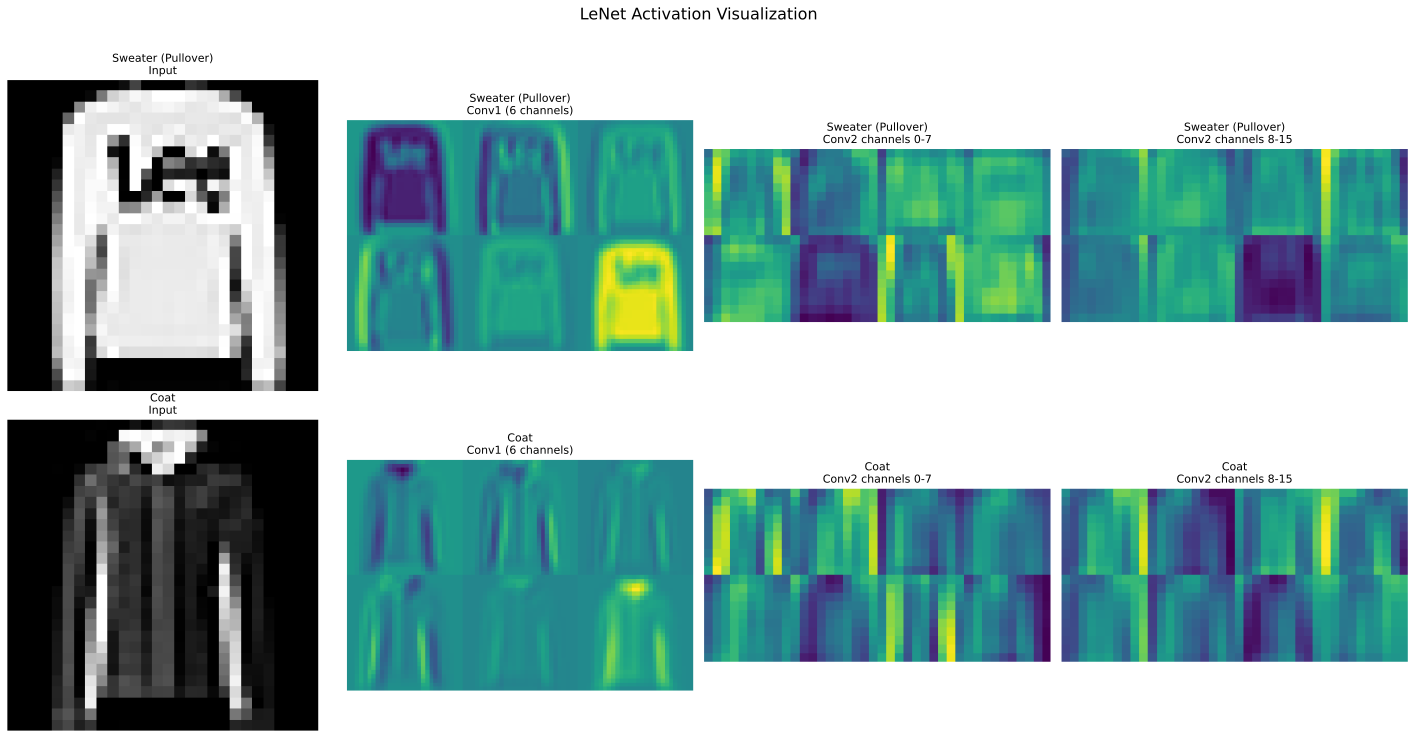

In [8]:
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# 获取Fashion-MNIST测试集中的毛衣(pullover, label=2)和外套(coat, label=4)样本
transform = transforms.ToTensor()
test_data_full = datasets.FashionMNIST(root='../data', train=False, download=True, transform=transform)

sweater_img = coat_img = None
for img, label in test_data_full:
    if label == 2 and sweater_img is None:
        sweater_img = img
    if label == 4 and coat_img is None:
        coat_img = img
    if sweater_img is not None and coat_img is not None:
        break

# 注册hook捕获激活值
activations = {}
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

net.eval()
net[0].register_forward_hook(get_activation('conv1'))  # 第一卷积层
net[3].register_forward_hook(get_activation('conv2'))  # 第二卷积层

device = next(iter(net.parameters())).device

inputs = {'pullover': sweater_img, 'coat': coat_img}
conv1_acts, conv2_acts = {}, {}
for name, img in inputs.items():
    with torch.no_grad():
        net(img.unsqueeze(0).to(device))
    conv1_acts[name] = activations['conv1'].cpu()
    conv2_acts[name] = activations['conv2'].cpu()

# 可视化
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for row, (name, label) in enumerate([('pullover', 'Sweater (Pullover)'), ('coat', 'Coat')]):
    img = inputs[name]
    c1 = conv1_acts[name]
    c2 = conv2_acts[name]
    
    # 原图
    axes[row, 0].imshow(img.squeeze(), cmap='gray')
    axes[row, 0].set_title(f'{label}\nInput', fontsize=11)
    axes[row, 0].axis('off')
    
    # Conv1 (6 channels) — 拼成 2×3 网格
    c1_grid = np.zeros((c1.shape[2] * 2, c1.shape[3] * 3))
    for i in range(6):
        r, c = divmod(i, 3)
        h, w = c1.shape[2], c1.shape[3]
        c1_grid[r*h:(r+1)*h, c*w:(c+1)*w] = c1[0, i].numpy()
    axes[row, 1].imshow(c1_grid, cmap='viridis')
    axes[row, 1].set_title(f'{label}\nConv1 (6 channels)', fontsize=11)
    axes[row, 1].axis('off')
    
    # Conv2 前8通道 (2×4)
    c2_grid1 = np.zeros((c2.shape[2] * 2, c2.shape[3] * 4))
    for i in range(8):
        r, c = divmod(i, 4)
        h, w = c2.shape[2], c2.shape[3]
        c2_grid1[r*h:(r+1)*h, c*w:(c+1)*w] = c2[0, i].numpy()
    axes[row, 2].imshow(c2_grid1, cmap='viridis')
    axes[row, 2].set_title(f'{label}\nConv2 channels 0-7', fontsize=11)
    axes[row, 2].axis('off')
    
    # Conv2 后8通道 (2×4)
    c2_grid2 = np.zeros((c2.shape[2] * 2, c2.shape[3] * 4))
    for i in range(8, 16):
        r, c = divmod(i - 8, 4)
        h, w = c2.shape[2], c2.shape[3]
        c2_grid2[r*h:(r+1)*h, c*w:(c+1)*w] = c2[0, i].numpy()
    axes[row, 3].imshow(c2_grid2, cmap='viridis')
    axes[row, 3].set_title(f'{label}\nConv2 channels 8-15', fontsize=11)
    axes[row, 3].axis('off')

plt.suptitle('LeNet Activation Visualization', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 小结

* 卷积神经网络（CNN）是一类使用卷积层的网络。
* 在卷积神经网络中，我们组合使用卷积层、非线性激活函数和汇聚层。
* 为了构造高性能的卷积神经网络，我们通常对卷积层进行排列，逐渐降低其表示的空间分辨率，同时增加通道数。
* 在传统的卷积神经网络中，卷积块编码得到的表征在输出之前需由一个或多个全连接层进行处理。
* LeNet是最早发布的卷积神经网络之一。